### [ OpenCV 활용한 이미지 데이터 증강(Data Augmentation) ]<hr>
- **데이터 증강(Data Augmentation)이란?**
    * 원본 이미지에 다양한 변형을 가해서 ==> 학습 데이터의 양을 늘리는 기법
    * 모델이 다양한 상황(각도/밝기/잡음 등)에 강해지도록 만들어 일반화 성능 ↑
    * 데이터가 적을 때 과대적합(overfitting)을 줄이는 데 효과적

- **증강 방법**   
    - **기하학적 변환 증강** (반전 · 회전 · 이동 · 자르기 · 기울이기)
    - **증강 파이프라인** (한 장 ➜ 여러 장)
    - **폴더 단위 일괄 증강** (실전 활용) 
<hr>



**[0]사전준비**
- 모듈 로딩
- 샘플 이미지 준비 (실습용 이미지가 없으면 테스트 이미지를 직접 생성)

In [1]:
## -----------------------------------------------------
## 모듈 로딩
## -----------------------------------------------------
import cv2                                                         ## 영상처리
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib                                        ## matplotlib 한글 폰트 설정
import os

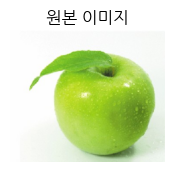

이미지 크기(shape) : (304, 358, 3)


In [ ]:
## -----------------------------------------------------
## 샘플 이미지 준비
## => 실습용 이미지 파일이 있으면 그 파일을 사용
## => 없으면 사과 모양과 비슷한 테스트 이미지를 직접 생성
## -----------------------------------------------------
# IMG_PATH = './apple_green.jpg'                            ## 실제 사용 시 본인 이미지 경로로 변경
IMG_PATH = './apple01.png'

if os.path.exists(IMG_PATH):
    imgNP = cv2.imread(IMG_PATH)
else:
    imgNP = np.full((200, 200, 3), 255, dtype=np.uint8)
    cv2.circle(imgNP, (100, 100), 70, (60, 60, 220), -1)     ## 빨간 몸통
    cv2.circle(imgNP, (100,  55), 10, (40, 120,  40), -1)    ## 초록 꼭지
    print(f"[안내] '{IMG_PATH}' 파일이 없어 테스트용 이미지를 생성했습니다.")

## OpenCV는 BGR 순서 ==> matplotlib 표시를 위해 RGB로 변환
img_rgb = cv2.cvtColor(imgNP, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(2, 2))
plt.imshow(img_rgb)
plt.title('원본 이미지')
plt.axis('off')
plt.show()

print(f"이미지 크기(shape) : {imgNP.shape}")

**[1] 기하학적 변환(Geometric Transformation) 증강**
- 어떤 도형이나 이미지의 점들을 구성하는 공간적 위치를 수학적 연산 통해 재배치
- 크기, 위치, 형태 등을 변경하는 처리 과정
- 방법들
    * 좌우/상하 반전 (flip)
    * 회전 (rotate)
    * 이동 (translate)
    * 무작위 자르기 (random crop)
    * 기울이기 (shear)

In [9]:
## -----------------------------------------------------
## (1) 좌우 / 상하 반전
## => cv2.flip(이미지, mode)
##    mode  1 : 좌우 반전  /  0 : 상하 반전  /  -1 : 좌우+상하 반전
## -----------------------------------------------------
def flip_image(img, mode=1):
    return cv2.flip(img, mode)


## -----------------------------------------------------
## (2) 회전
## => cv2.getRotationMatrix2D(중심점, 각도, 스케일)  ==> 회전 행렬 생성
## => cv2.warpAffine(이미지, 회전행렬, 출력크기)      ==> 회전 행렬 적용
## -----------------------------------------------------
def rotate_image(img, angle, scale=1.0):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, scale)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)


## -----------------------------------------------------
## (3) 이동 (평행이동)
## => 이동 행렬 [[1, 0, tx], [0, 1, ty]] 직접 구성 후 warpAffine 적용
## -----------------------------------------------------
def translate_image(img, tx, ty):
    h, w = img.shape[:2]
    M = np.float32([[1, 0, tx],
                     [0, 1, ty]])
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)


## -----------------------------------------------------
## (4) 무작위 자르기(random crop) 후 원본 크기로 리사이즈
## => 객체의 위치/크기가 항상 같지 않도록 만들어 다양성 ↑
## -----------------------------------------------------
def random_crop(img, crop_ratio=0.8):
    h, w = img.shape[:2]
    ch, cw = int(h * crop_ratio), int(w * crop_ratio)
    y = np.random.randint(0, h - ch + 1)
    x = np.random.randint(0, w - cw + 1)
    cropped = img[y:y+ch, x:x+cw]
    return cv2.resize(cropped, (w, h))


## -----------------------------------------------------
## (5) 기울이기 (shear)
## => 어파인 변환 행렬에 기울임 계수를 추가해서 비스듬하게 변형
## -----------------------------------------------------
def shear_image(img, shear_factor=0.2):
    h, w = img.shape[:2]
    M = np.float32([[1, shear_factor, 0],
                     [0, 1,           0]])
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

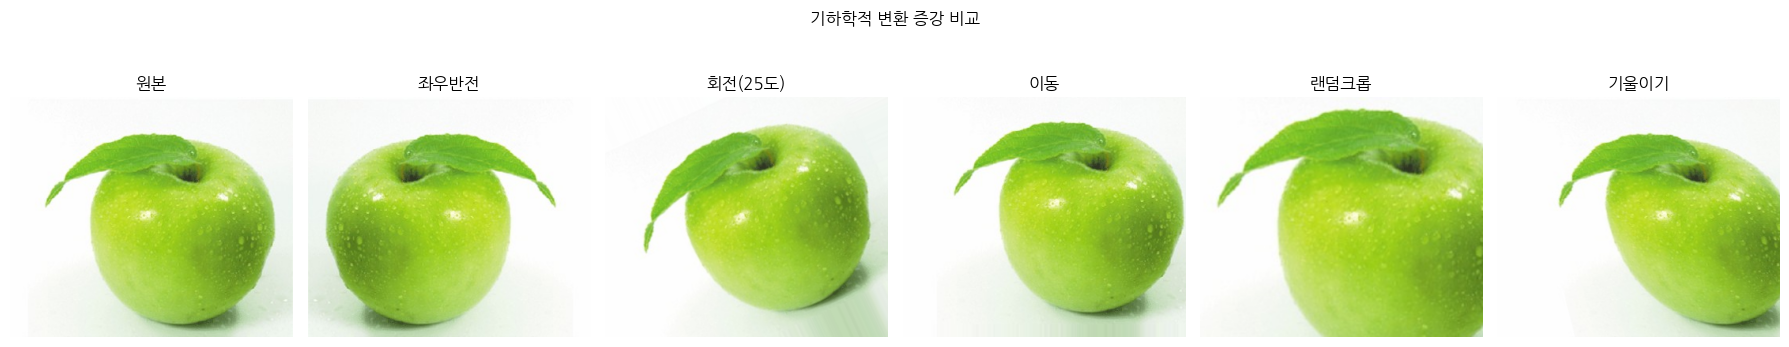

In [10]:
## -----------------------------------------------------------
## 기하학적 변환 결과 비교
## -----------------------------------------------------------
geo_results = { '원본'       : imgNP,
                '좌우반전'   : flip_image(imgNP, 1),
                '회전(25도)' : rotate_image(imgNP, 25),
                '이동'       : translate_image(imgNP, 20, -15),
                '랜덤크롭'   : random_crop(imgNP, 0.75),
                '기울이기'   : shear_image(imgNP, 0.25),
}

## => 시각화
fig, axes = plt.subplots(1, len(geo_results), figsize=(18, 4))
for ax, (title, im) in zip(axes, geo_results.items()):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.suptitle('기하학적 변환 증강 비교')
plt.tight_layout()
plt.show()

**[2] 픽셀값 변환 증강**
- 밝기 / 대비(brightness / contrast) 조절
- 가우시안 노이즈(noise) 추가
- 블러(blur) 처리

In [11]:
## -----------------------------------------------------
## (1) 밝기 / 대비 조절
## => cv2.convertScaleAbs(이미지, alpha=대비, beta=밝기)
##    결과 = 원본 * alpha + beta   (0~255로 자동 클리핑)
## -----------------------------------------------------
def adjust_brightness_contrast(img, brightness=0, contrast=1.0):
    return cv2.convertScaleAbs(img, alpha=contrast, beta=brightness)


## -----------------------------------------------------
## (2) 가우시안 노이즈 추가
## => 정규분포(평균 0, 표준편차 sigma) 노이즈를 픽셀값에 더함
## => 촬영 환경/센서 잡음을 흉내내어 모델을 더 강건하게 만듦
## -----------------------------------------------------
def add_gaussian_noise(img, sigma=15):
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


## -----------------------------------------------------
## (3) 블러(흐림) 처리
## => cv2.GaussianBlur(이미지, (커널크기, 커널크기), 표준편차)
## => 초점이 안 맞은 사진/저화질 상황을 흉내냄
## -----------------------------------------------------
def gaussian_blur(img, ksize=5):
    return cv2.GaussianBlur(img, (ksize, ksize), 0)

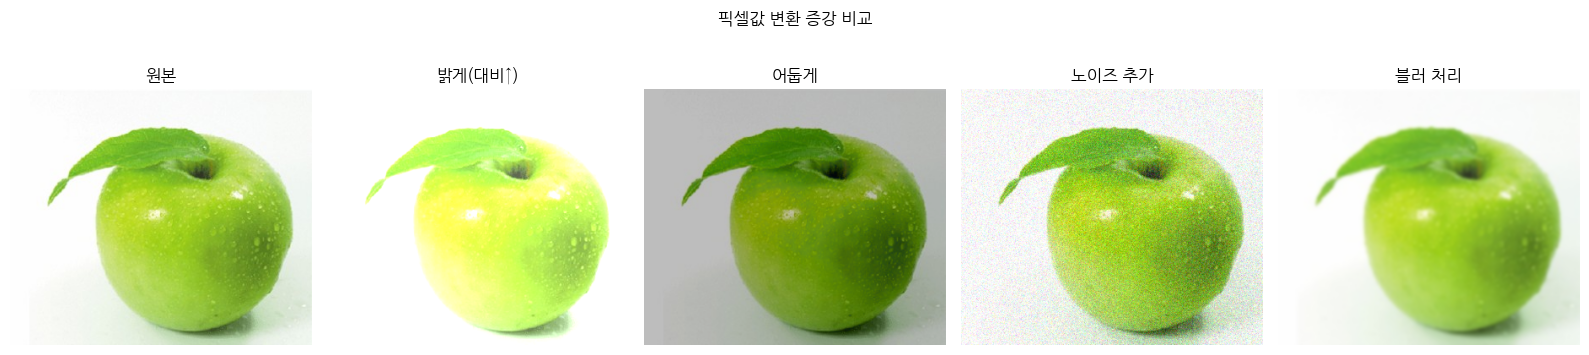

In [12]:
## -----------------------------------------------------------
## 픽셀값 변환 결과 비교
## -----------------------------------------------------------
pixel_results = {   '원본'        : imgNP,
                    '밝게(대비↑)' : adjust_brightness_contrast(imgNP, brightness=40,  contrast=1.2),
                    '어둡게'      : adjust_brightness_contrast(imgNP, brightness=-40, contrast=0.9),
                    '노이즈 추가'  : add_gaussian_noise(imgNP, sigma=20),
                    '블러 처리'    : gaussian_blur(imgNP, 9),
}

## => 시각화
fig, axes = plt.subplots(1, len(pixel_results), figsize=(16, 4))
for ax, (title, im) in zip(axes, pixel_results.items()):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.suptitle('픽셀값 변환 증강 비교')
plt.tight_layout()
plt.show()

**[3] 증강 파이프라인**
- 함수들을 무작위로 조합 ==> 원본 1장에서 N장의 새 이미지 생성
- 실제 학습 데이터셋을 늘릴 때 사용하는 방식

In [13]:
## -----------------------------------------------------
## 증강 파이프라인 : 호출할 때마다 무작위로 기법을 조합해서 적용
## -----------------------------------------------------
## 함수기능 : augment_image
## 함수이름 : augment_image
## 매개변수 : img  원본 ndarray 데이터
## 반환결과 : 증강된 img ndarray 데이터
## -----------------------------------------------------
def augment_image(img):
    result = img.copy()

    ## 1) 50% 확률로 좌우 반전
    if np.random.rand() < 0.5:
        result = flip_image(result, 1)

    ## 2) -20 ~ 20도 사이 무작위 회전
    angle = np.random.uniform(-20, 20)
    result = rotate_image(result, angle)

    ## 3) -10 ~ 10픽셀 사이 무작위 이동
    tx, ty = np.random.randint(-10, 11, size=2)   ## -10<= ~ <11
    result = translate_image(result, tx, ty)

    ## 4) 밝기 무작위 조절
    brightness = np.random.randint(-30, 31)
    result = adjust_brightness_contrast(result, brightness=brightness, contrast=1.0)

    ## 5) 30% 확률로 노이즈 추가
    if np.random.rand() < 0.3:
        result = add_gaussian_noise(result, sigma=10)

    return result


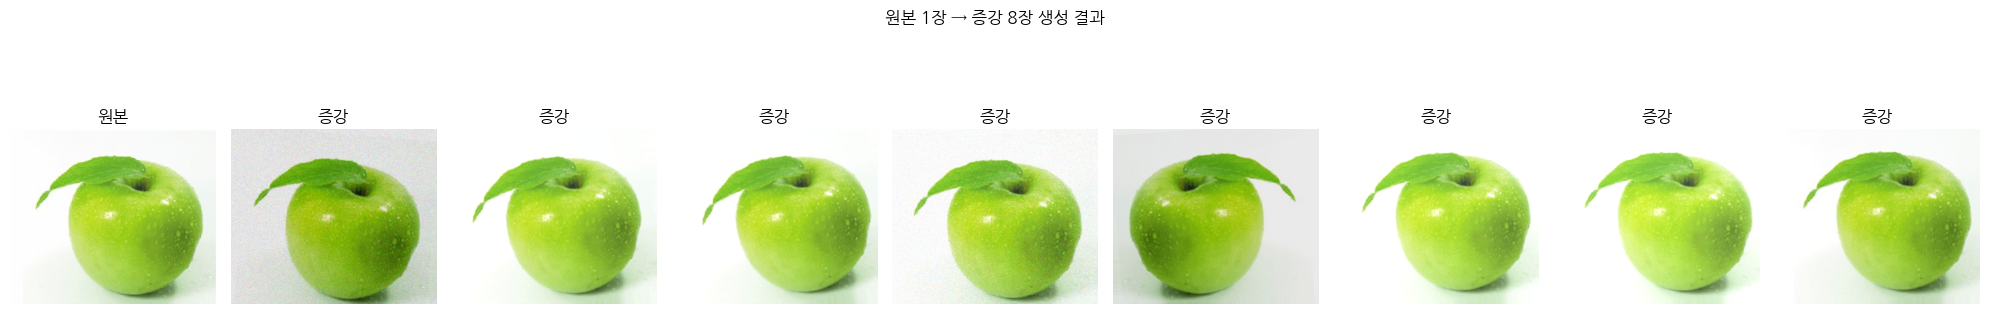

In [ ]:
## -------------------------------------------------------
##=> 원본 이미지 1장으로 8장의 증강 이미지 생성
## -------------------------------------------------------
N_AUG = 8
augmented_list = [imgNP] + [augment_image(imgNP) for _ in range(N_AUG)]
title_list = ['원본'] + (['증강'] * 8)

fig, axes = plt.subplots(1, N_AUG + 1, figsize=(20, 4))
for ax, data, title in zip(axes, augmented_list, title_list):
    ax.imshow(cv2.cvtColor(data, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')

plt.suptitle('원본 1장 → 증강 8장 생성 결과')
plt.tight_layout()
plt.show()

- **[4] 폴더 단위 일괄 증강 (실전 활용)**
    * 사과/바나나 분류 학습 데이터셋처럼 폴더 안의 이미지 전체를 증강
    * 이미지 1장당 N장씩 증강본을 만들어 저장 ==> 학습 데이터 양 증가

In [ ]:
## ---------------------------------------------------------
## 폴더 단위 일괄 증강 함수
## => src_dir 이미지들 ==> 각각 n_aug장씩 증강 후 dst_dir에 저장
## ---------------------------------------------------------
## 함수기능 : augment_folder
## 함수이름 : augment_image
## 매개변수 : src_dir                        소스 폴더 
##           dst_dir                        증강된 이미지 저장 폴더
##           n_aug=5                        증강 횟수
##           exts=('.jpg', '.jpeg', '.png') 허용 파일확장자
## 반환결과 : 증강된 img ndarray 데이터
## ---------------------------------------------------------
def augment_folder(src_dir, dst_dir, n_aug=5, exts=('.jpg', '.jpeg', '.png')):
    ## 증강 이미지 저장 폴더 생성
    os.makedirs(dst_dir, exist_ok=True)

    ## 허용된 확장자의 파일 리스트만 추출
    files = [f for f in os.listdir(src_dir) if f.lower().endswith(exts)]

    ## 총 증강 후 저장된 파일 갯수 체크
    total_saved = 0

    ## 파일별 증강 진행 
    for fname in files:
        
        # 읽기 실패하면 뭐시기
        filepath = os.path.join(src_dir, fname)
        src_img  = cv2.imread(filepath)
        if src_img is None:
            continue

        name, ext = os.path.splitext(fname)

        ## 원본도 함께 저장 (선택)
        # cv2.imwrite(os.path.join(dst_dir, f'{name}_orig{ext}'), src_img)

        # 이미지 증강 후 저장
        for i in range(n_aug):
            aug_img   = augment_image(src_img)
            save_path = os.path.join(dst_dir, f'{name}_aug{i}{ext}')
            cv2.imwrite(save_path, aug_img)
            total_saved += 1

    print(f"[완료] 원본 {len(files)}장 ==> 증강 {total_saved}장 생성 (저장 위치 : {dst_dir})")




In [18]:
APPLE_SRC  = '../Data/Images/apple'
BANANA_SRC = '../Data/Images/banana'
APPLE_AUG  = '../Data/AB_AUG/apple'
BANANA_AUG = '../Data/AB_AUG/banana'

augment_folder(APPLE_SRC, APPLE_AUG, n_aug=4)
augment_folder(BANANA_SRC, BANANA_AUG, n_aug=4)

[완료] 원본 58장 ==> 증강 232장 생성 (저장 위치 : ../Data/AB_AUG/apple)
[완료] 원본 30장 ==> 증강 120장 생성 (저장 위치 : ../Data/AB_AUG/banana)


In [ ]:
## -----------------------------------------------------
## 동작 테스트 : 위에서 준비한 이미지로 실제 폴더 증강 실행
## -----------------------------------------------------
DEMO_SRC = './demo_src'
DEMO_DST = './demo_aug'

os.makedirs(DEMO_SRC, exist_ok=True)
cv2.imwrite(os.path.join(DEMO_SRC, 'apple_sample.jpg'), imgNP)

augment_folder(DEMO_SRC, DEMO_DST, n_aug=4)

print('생성된 파일 목록 :')
for f in sorted(os.listdir(DEMO_DST)):
    print(' -', f)

[완료] 원본 1장 ==> 증강 4장 생성 (저장 위치 : ./demo_aug)
생성된 파일 목록 :
 - apple_sample_aug0.jpg
 - apple_sample_aug1.jpg
 - apple_sample_aug2.jpg
 - apple_sample_aug3.jpg
 - apple_sample_orig.jpg


**[핵심 정리]**
- OpenCV 함수(`flip`, `warpAffine`, `convertScaleAbs`, `GaussianBlur` 등)로 충분히 증강 구현 가능
- 실전에서는 `albumentations`, `imgaug` 같은 전용 라이브러리도 많이 사용 (더 다양한 기법 + 빠른 속도)
- 증강한 이미지로 데이터셋 늘린 뒤, 학습/평가/교차검증 코드에 그대로 연결해서 성능 변화 비교해보면 좋음